In [ ]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
%load_ext sql

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [ ]:
%sql sqlite:///inventory.db

In [ ]:
conn = sqlite3.connect('inventory.db')
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)


In [ ]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [ ]:
for table in tables['name']:
  print('Table Name:', table)
  df= pd.read_sql_query(f"SELECT * FROM {table} limit 5",conn)
  display(df)

Table Name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table Name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table Name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table Name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table Name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [ ]:
vendor_df  = pd.read_sql_query("SELECT * FROM vendor_invoice",conn)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [ ]:
vendor_df[['Quantity','Dollars','Freight']].corr()

,Quantity,Dollars,Freight
Quantity,1.000000,0.963831,0.946550
Dollars,0.963831,1.000000,0.985141
Freight,0.946550,0.985141,1.000000


array([[<Axes: xlabel='Quantity', ylabel='Quantity'>,
        <Axes: xlabel='Dollars', ylabel='Quantity'>,
        <Axes: xlabel='Freight', ylabel='Quantity'>],
       [<Axes: xlabel='Quantity', ylabel='Dollars'>,
        <Axes: xlabel='Dollars', ylabel='Dollars'>,
        <Axes: xlabel='Freight', ylabel='Dollars'>],
       [<Axes: xlabel='Quantity', ylabel='Freight'>,
        <Axes: xlabel='Dollars', ylabel='Freight'>,
        <Axes: xlabel='Freight', ylabel='Freight'>]], dtype=object)

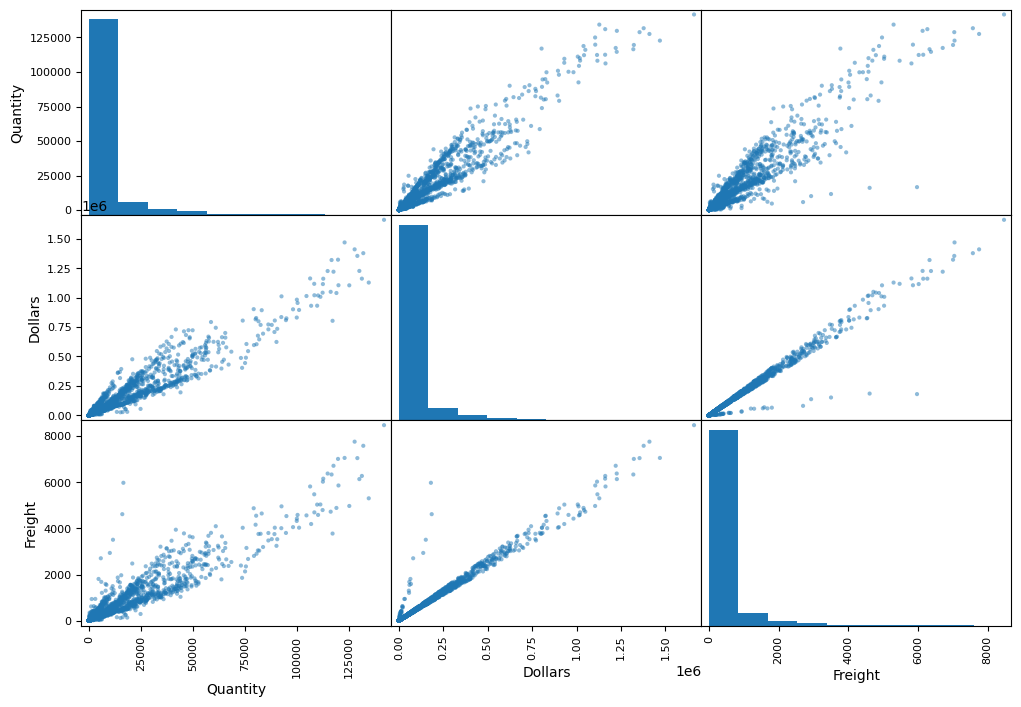

In [ ]:
from pandas.plotting import scatter_matrix
attributes = ['Quantity','Dollars','Freight']
scatter_matrix(vendor_df[attributes],figsize=(12,8))
#vendor_df.plot(kind='scatter',x='Quantity',y='Freight',alpha = 0.8)
#vendor_df.plot(kind='scatter',x='Dollars',y='Freight',alpha = 0.8)


In [ ]:
vendor_df['Freight_per_unit'] = vendor_df['Freight']/vendor_df['Quantity']
vendor_df.head(2)

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,Freight_per_unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None,0.571333


In [ ]:
vendor_df.describe()

,VendorNumber,PONumber,Quantity,Dollars,Freight,Freight_per_unit
count,5543.00000,5543.000000,5543.000000,5.543000e+03,5543.000000,5543.000000
mean,20662.75212,10889.419087,6058.880931,5.807338e+04,295.954301,0.068242
std,34582.15841,1600.859969,14453.338164,1.402340e+05,713.585093,0.084333
min,2.00000,8106.000000,1.000000,4.140000e+00,0.020000,0.005367
25%,3089.00000,9503.500000,83.000000,9.678100e+02,5.020000,0.038561
50%,7240.00000,10890.000000,423.000000,4.765450e+03,24.730000,0.050824
75%,10754.00000,12275.500000,5100.500000,4.458718e+04,229.660000,0.074710
max,201359.00000,13661.000000,141660.000000,1.660436e+06,8468.220000,3.106000


**We will check now ehether Freight cost differs with bulk and lower quantity orders.**

In [ ]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
High_quantity = vendor_df['Quantity'].quantile(0.75)
print(f'low_quantity: {low_quantity}')
print(f'High_quantity: {High_quantity}')

low_quantity: 83.0
High_quantity: 5100.5


In [ ]:
#Check Freight cost Difference
low_quantity_df = vendor_df[vendor_df['Quantity']<low_quantity]
high_quantity_df = vendor_df[vendor_df['Quantity']>High_quantity]
print('Low Quantity Orders')
display(low_quantity_df.describe())
print('High Quantity Orders')
display(high_quantity_df.describe())

Low Quantity Orders


,VendorNumber,PONumber,Quantity,Dollars,Freight,Freight_per_unit
count,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000
mean,35682.605491,10705.927023,32.550578,491.233707,2.644530,0.094899
std,47163.062952,1597.993884,22.762416,537.123597,2.987994,0.142101
min,2.000000,8107.000000,1.000000,4.140000,0.020000,0.011667
25%,2450.000000,9302.250000,12.000000,165.000000,0.870000,0.044167
50%,9260.000000,10646.000000,25.500000,362.440000,1.910000,0.069152
75%,90017.000000,12112.250000,48.000000,644.280000,3.452500,0.104171
max,201359.000000,13660.000000,82.000000,8380.320000,45.250000,3.106000


High Quantity Orders


,VendorNumber,PONumber,Quantity,Dollars,Freight,Freight_per_unit
count,1386.000000,1386.000000,1386.000000,1.386000e+03,1386.000000,1386.000000
mean,6851.140693,11022.946609,21941.704185,2.070033e+05,1049.345505,0.049078
std,4142.669507,1572.023274,22244.284919,2.201387e+05,1122.080070,0.028447
min,480.000000,8106.000000,5102.000000,5.908820e+03,28.950000,0.005367
25%,3252.000000,9740.000000,7739.250000,6.436248e+04,327.560000,0.034074
50%,8004.000000,11093.500000,12894.000000,1.250478e+05,634.670000,0.041126
75%,9815.000000,12395.250000,27383.500000,2.635896e+05,1340.362500,0.055929
max,17035.000000,13658.000000,141660.000000,1.660436e+06,8468.220000,0.468458


**We could clearly see the mean value of Fright cost for Low & High is 0.0948.. & 0.0490..**

In [ ]:
X = vendor_df[['Dollars']]
Y = vendor_df['Freight']


**Train - Test Split**

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
model1 = LinearRegression()
model2 = DecisionTreeRegressor(random_state=42,max_depth=3)
model3 = RandomForestRegressor(random_state=42,max_depth=3)

In [ ]:
model1.fit(X_train,Y_train)
model2.fit(X_train,Y_train)
model3.fit(X_train,Y_train)


RandomForestRegressor(max_depth=3, random_state=42)

In [ ]:
def evaluate_model(model,X_test,Y_test,model_name):
  Y_pred = model.predict(X_test)
  mse = mean_squared_error(Y_test,Y_pred)
  mae = mean_absolute_error(Y_test,Y_pred)
  r2 = r2_score(Y_test,Y_pred)
  print(f'Model Name: {model_name}')
  print(f'MSE: {mse}')
  print(f'MAE: {mae}')
  print(f'R2 Score: {r2*100:.2f}%')

In [ ]:
evaluate_model(model1,X_test, Y_test,'Linear Regression')

Model Name: Linear Regression
MSE: 15555.318371054229
MAE: 24.1059770728758
R2 Score: 96.99%


In [ ]:
evaluate_model(model2,X_test, Y_test,'Decission Tree')

Model Name: Decission Tree
MSE: 28928.076238535665
MAE: 65.94922852263386
R2 Score: 94.40%


In [ ]:
evaluate_model(model3,X_test, Y_test,'Random Forest')

Model Name: Random Forest
MSE: 19638.95899663542
MAE: 39.464030342851956
R2 Score: 96.20%


0.03 8468.22


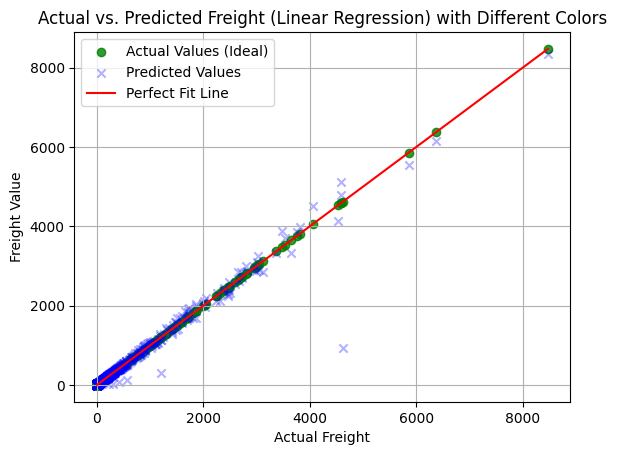

In [ ]:
plt.scatter(Y_test, Y_test, color='green', label='Actual Values (Ideal)', marker='o', alpha=0.8)
plt.scatter(Y_test, model1.predict(X_test), color='blue', label='Predicted Values', marker='x', alpha=0.3)
plt.plot([Y_test.min(),  Y_test.max()], [Y_test.min(),  Y_test.max()], color='red', linestyle='-', label='Perfect Fit Line')
print(Y_test.min(),  Y_test.max())
plt.xlabel('Actual Freight')
plt.ylabel('Freight Value')
plt.title('Actual vs. Predicted Freight (Linear Regression) with Different Colors')
plt.legend()
plt.grid(True)
plt.show()

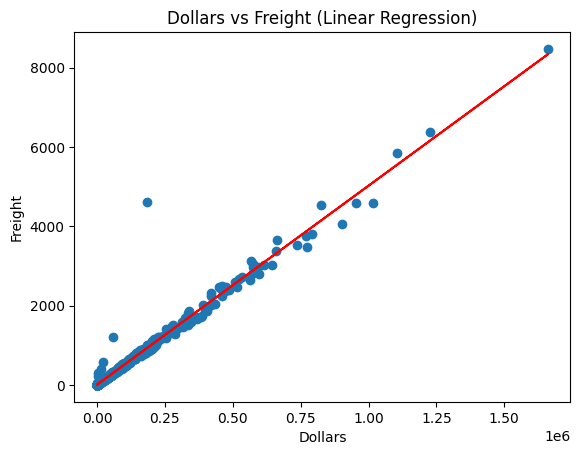

In [ ]:
plt.scatter(X_test,Y_test)
plt.plot(X_test,model1.predict(X_test),color='red')
plt.xlabel('Dollars')
plt.ylabel('Freight')
plt.title('Dollars vs Freight (Linear Regression)')
plt.show()

In [ ]:
input_data = {
    "Dollars" : [18500,9000]
}
input_df = pd.DataFrame(input_data)

In [ ]:
model1.predict(input_df)

array([97.78868161, 50.14455838])